# Régression PFAS — Concentration totale (log₁₀ Σ PFAS)

**Objectif :** Prédire l'**intensité de contamination** d'un puits californien, mesurée par la
somme des 31 composés PFAS (`sum_pfas_ngL`), à partir des variables environnementales.

**Cible :** `log₁₀(sum_pfas_ngL + 1)` — la transformation log corrige une asymétrie extrême
(skew brut = 6.1 → skew log = 1.56) et linéarise la dynamique de contamination
(médiane 32 ng/L, P95 552 ng/L, max 5 723 ng/L).

**Complément** du notebook `01_binary_classification_epa2024` : là où la classification répond
*« le puits dépasse-t-il la norme ? »*, la régression répond *« à quel point est-il contaminé ? »*.

**Modèles :** Random Forest Regressor + XGBoost Regressor, optimisés par Optuna.

> ⚠️ `sum_pfas_ngL` inclut des valeurs substituées pour les non-détects (≈ ½ LDM). Le « plancher »
> de contamination (~32 ng/L médian) reflète donc en partie la substitution analytique, pas
> uniquement une contamination réelle. Voir `docs/rapport_variables_cibles.md`.

## 0. Imports et configuration

In [1]:
import warnings
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    median_absolute_error,
)
from scipy.stats import spearmanr

import xgboost as xgb

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ── Chemins ──────────────────────────────────────────────────────────────────
PROJECT_ROOT  = Path("..")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR    = PROJECT_ROOT / "models"
FIGURES_DIR   = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
RANDOM_STATE = 42
print("Imports OK")

Imports OK


## 1. Chargement des données

In [2]:
df = pd.read_parquet(PROCESSED_DIR / "CA-PFAS-ASGWS.parquet")
print(f"Dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
df.head(3)

Dataset : 46,338 lignes × 201 colonnes


,gm_well_id,collection_date,ADONA_ngL,F53B_major_ngL,F53B_minor_ngL,FTS_4_2_ngL,FTS_6_2_ngL,FTS_8_2_ngL,HFPO_DA_ngL,NEtFOSAA_ngL,...,runoff_mm,soil_moi_0_10_kg_m2,soil_moi_10_40_kg_m2,soil_moi_40_100_kg_m2,soil_moi_100_200_kg_m2,root_zone_moist_kg_m2,temp_c,snowpack_mm,gldas_dist_km,soil_moisture_total_mm
0,100001,2019-03-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.35,...,0.000506,23.504955,73.092522,149.431152,239.711273,50.487106,15.603387,0.0,14.443,485.739902
1,100001,2020-04-28,1.0,1.0,1.0,NaN,NaN,NaN,2.5,1.00,...,0.000722,23.421059,72.313629,145.745392,232.140076,45.648960,17.293207,0.0,14.443,473.620155
2,100002,2019-03-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.35,...,0.000506,23.504955,73.092522,149.431152,239.711273,50.487106,15.603387,0.0,14.443,485.739902


## 2. Construction de la cible — log₁₀(Σ PFAS)

La somme PFAS est extrêmement asymétrique. On applique `log₁₀(x + 1)` :
- le `+1` évite `log(0)` pour les très rares échantillons à somme nulle,
- la transformation ramène le skew de 6.1 à ~1.5, adapté à une régression.

In [3]:
# Cible brute et transformée
df = df[df["sum_pfas_ngL"].notna()].copy()   # retirer les rares NaN sur la cible
y_raw  = df["sum_pfas_ngL"].values
y_log  = np.log10(y_raw + 1.0)
df["target_log_sum"] = y_log

print(f"Échantillons avec cible valide : {len(df):,}")
print(f"\nsum_pfas_ngL (brut)  : médiane={np.median(y_raw):.1f}  moyenne={y_raw.mean():.1f}  "
      f"P95={np.percentile(y_raw,95):.0f}  max={y_raw.max():.0f}")
print(f"log10(sum+1)         : médiane={np.median(y_log):.3f}  moyenne={y_log.mean():.3f}  "
      f"min={y_log.min():.3f}  max={y_log.max():.3f}")
print(f"Skew brut={pd.Series(y_raw).skew():.2f}  →  Skew log={pd.Series(y_log).skew():.2f}")

Échantillons avec cible valide : 46,338

sum_pfas_ngL (brut)  : médiane=32.3  moyenne=174.0  P95=552  max=5723
log10(sum+1)         : médiane=1.522  moyenne=1.664  min=0.000  max=3.758
Skew brut=6.11  →  Skew log=1.56


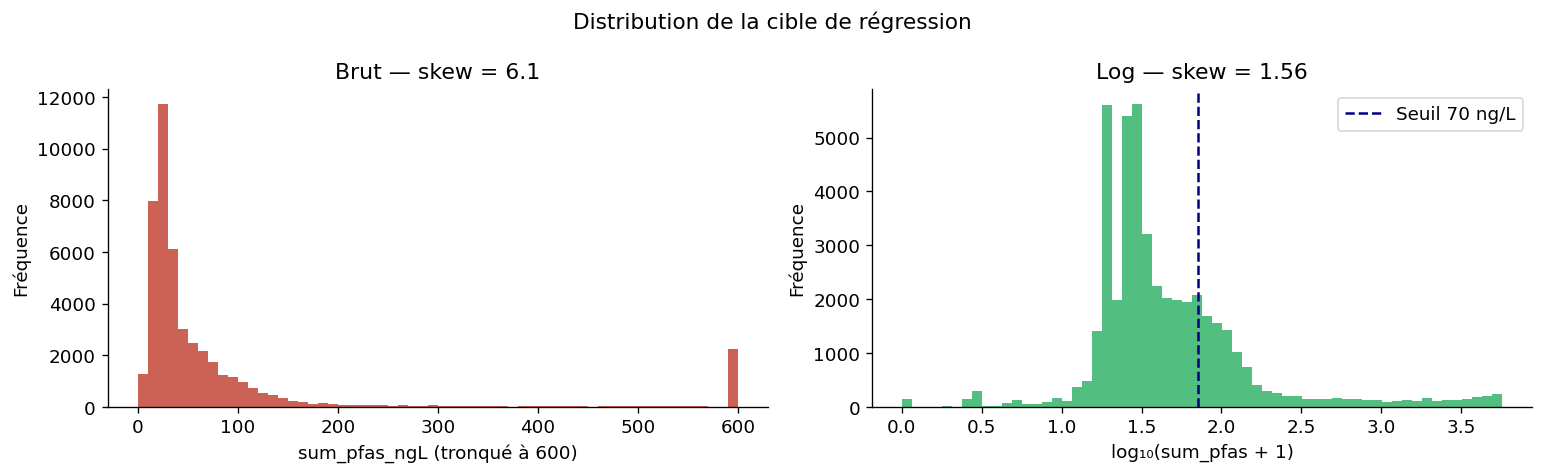

In [4]:
# Distribution avant / après transformation log
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(np.clip(y_raw, 0, 600), bins=60, color="#c0392b", alpha=0.8)
axes[0].set_xlabel("sum_pfas_ngL (tronqué à 600)")
axes[0].set_ylabel("Fréquence")
axes[0].set_title(f"Brut — skew = {pd.Series(y_raw).skew():.1f}")

axes[1].hist(y_log, bins=60, color="#27ae60", alpha=0.8)
axes[1].axvline(np.log10(70+1), color="navy", ls="--", lw=1.5,
                label="Seuil 70 ng/L")
axes[1].set_xlabel("log₁₀(sum_pfas + 1)")
axes[1].set_ylabel("Fréquence")
axes[1].set_title(f"Log — skew = {pd.Series(y_log).skew():.2f}")
axes[1].legend()

fig.suptitle("Distribution de la cible de régression", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "reg_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Ingénierie des features

**Identique au notebook de classification** : on exclut les 3 types de fuite
(`_ngL`, `_detected`/`label_`, ancienne cible) et le bruit (`gldas_dist_km`,
colonnes > 90 % manquantes). Cohérence stricte entre les deux modèles.

In [5]:
# ── Features temporelles ─────────────────────────────────────────────────────
dt = pd.to_datetime(df["collection_date"])
df["year"]   = dt.dt.year
df["month"]  = dt.dt.month
df["season"] = ((dt.dt.month % 12) // 3 + 1).astype(int)

# ── Colonnes à exclure — fuite + bruit (identique au notebook classification) ─
LEAK_SUFFIXES      = ("_ngL",)
LEAK_BOOL_SUFFIXES = ("_detected",)
LEAK_PREFIXES      = ("label_",)
LEAK_EXACT = {
    "sum_pfas_ngL", "pfas_class_assignment", "gm_well_id",
    "collection_date", "target", "target_log_sum", "target_sum_gt70",
    "gldas_dist_km",
}
HIGH_NULL_DROP = {
    "cocontam_xylenes", "cocontam_tmb124", "cocontam_dce12c", "cocontam_btbzt",
    "soil_gradation_uniformity", "soil_gradation_curvature",
    "soil_silt_coarse_pct", "soil_silt_fine_pct", "cocontam_no3n", "well_depth_ft",
}
DROP_REDUNDANT = {"dwr_basin", "sgma_basin_name", "sgma_subbasin_name"}

CATEGORICAL_FEATURES = [
    "gm_well_category", "nearest_geotracker_type", "soil_texture_class",
    "sgma_region_office", "gm_dataset_name", "county", "regional_board", "dwr_region",
]
cat_cols = [c for c in CATEGORICAL_FEATURES if c in df.columns]

num_cols = [
    c for c in df.columns
    if df[c].dtype.kind in ("f", "i", "u")
    and not any(c.endswith(s) for s in LEAK_SUFFIXES)
    and not any(c.endswith(s) for s in LEAK_BOOL_SUFFIXES)
    and not any(c.startswith(p) for p in LEAK_PREFIXES)
    and c not in LEAK_EXACT
    and c not in HIGH_NULL_DROP
    and c not in DROP_REDUNDANT
    and c not in cat_cols
]

feature_names = num_cols + cat_cols
print(f"Features numériques   : {len(num_cols)}")
print(f"Features catégorielles : {len(cat_cols)}")
print(f"TOTAL                 : {len(feature_names)}")

X = df[feature_names].copy()
y = df["target_log_sum"].values
print(f"\nMatrice X : {X.shape}")

Features numériques   : 84
Features catégorielles : 8
TOTAL                 : 92

Matrice X : (46338, 92)


In [6]:
# Taux de valeurs manquantes par groupe
missing = X.isna().mean().sort_values(ascending=False)
top_missing = missing[missing > 0].head(15)
if len(top_missing):
    print("Top features avec valeurs manquantes :")
    for c, m in top_missing.items():
        print(f"  {c:<32} {100*m:5.1f}%")
else:
    print("Aucune valeur manquante.")

Top features avec valeurs manquantes :
  aqs_so2_ppb                       34.6%
  cocontam_mn                       31.3%
  cocontam_as                       31.3%
  cocontam_tds                      31.3%
  cocontam_so4                      31.3%
  cocontam_fe                       20.3%
  aqs_co_ppm                        16.1%
  cocontam_fc11                     10.2%
  cocontam_btbzn                    10.2%
  cocontam_fc113                    10.2%
  cocontam_dcbz13                   10.2%
  cocontam_pca                      10.2%
  cocontam_fc12                     10.2%
  soil_ph                            8.3%
  soil_ratio_water_clay              7.9%


## 4. Prétraitement et split train/test

Split 80/20 **stratifié sur déciles de la cible** : garantit que la gamme complète
de contamination (faible → extrême) est représentée dans train et test.

In [7]:
# Stratification sur déciles de la cible continue
y_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y_bins
)
print(f"Train : {len(y_train):,}  (médiane log={np.median(y_train):.3f})")
print(f"Test  : {len(y_test):,}   (médiane log={np.median(y_test):.3f})")

# ── Préprocesseur sklearn (identique classification) ─────────────────────────
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1,
        encoded_missing_value=-1,
    )),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
], remainder="drop")

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)
print(f"\nX_train_proc : {X_train_proc.shape}")

Train : 37,070  (médiane log=1.522)
Test  : 9,268   (médiane log=1.522)

X_train_proc : (37070, 92)


## 5. Fonctions utilitaires (métriques + graphiques)

In [8]:
def evaluate_regression(name, y_true, y_pred):
    """Métriques de régression sur l'échelle log ET sur l'échelle originale (ng/L)."""
    # ── Échelle log (celle de l'apprentissage) ───────────────────────────────
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)
    rho, _ = spearmanr(y_true, y_pred)

    # ── Échelle originale (ng/L) — retransformation 10^x - 1 ─────────────────
    yt_ngl = np.power(10, y_true) - 1
    yp_ngl = np.power(10, y_pred) - 1
    rmse_ngl  = np.sqrt(mean_squared_error(yt_ngl, yp_ngl))
    medae_ngl = median_absolute_error(yt_ngl, yp_ngl)

    print(f"{'═'*58}")
    print(f"  {name}")
    print(f"{'─'*58}")
    print(f"  [échelle log10]")
    print(f"    R²                    : {r2:.4f}")
    print(f"    RMSE                  : {rmse:.4f}")
    print(f"    MAE                   : {mae:.4f}")
    print(f"    Median AE             : {medae:.4f}")
    print(f"    Spearman ρ (rang)     : {rho:.4f}")
    print(f"  [échelle ng/L]")
    print(f"    RMSE                  : {rmse_ngl:.1f} ng/L")
    print(f"    Median AE             : {medae_ngl:.1f} ng/L")
    print(f"{'═'*58}")
    return {"name": name, "r2": r2, "rmse": rmse, "mae": mae,
            "medae": medae, "spearman": rho,
            "rmse_ngl": rmse_ngl, "medae_ngl": medae_ngl}


def plot_pred_vs_actual(models_results, y_test, title=""):
    """Scatter prédit vs réel + résidus pour plusieurs modèles."""
    n = len(models_results)
    fig, axes = plt.subplots(2, n, figsize=(6*n, 10))
    if n == 1:
        axes = axes.reshape(2, 1)
    palette = ["#2980b9", "#e74c3c", "#27ae60", "#8e44ad"]
    lim = [y_test.min() - 0.2, y_test.max() + 0.2]

    for i, (name, y_pred, metrics) in enumerate(models_results):
        color = palette[i % len(palette)]
        # ── Prédit vs réel ───────────────────────────────────────────────────
        ax = axes[0, i]
        ax.scatter(y_test, y_pred, s=6, alpha=0.25, color=color, edgecolors="none")
        ax.plot(lim, lim, "k--", lw=1.5, label="y = x")
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel("log₁₀(Σ PFAS) réel")
        ax.set_ylabel("log₁₀(Σ PFAS) prédit")
        ax.set_title(f"{name}\nR² = {metrics['r2']:.3f} | ρ = {metrics['spearman']:.3f}")
        ax.legend(loc="upper left")
        ax.grid(alpha=0.3)
        # ── Résidus ──────────────────────────────────────────────────────────
        ax = axes[1, i]
        resid = y_pred - y_test
        ax.scatter(y_pred, resid, s=6, alpha=0.25, color=color, edgecolors="none")
        ax.axhline(0, color="k", ls="--", lw=1.5)
        ax.set_xlabel("log₁₀(Σ PFAS) prédit")
        ax.set_ylabel("Résidu (prédit − réel)")
        ax.set_title(f"{name} — résidus (σ = {resid.std():.3f})")
        ax.grid(alpha=0.3)

    if title:
        fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "reg_pred_vs_actual.png", dpi=150, bbox_inches="tight")
    plt.show()

print("Fonctions utilitaires prêtes.")

Fonctions utilitaires prêtes.


## 6. Random Forest Regressor

In [9]:
# ── Paramètres RF ────────────────────────────────────────────────────────────
RF_PARAMS = {
    "n_estimators":     500,
    "max_features":     "sqrt",
    "min_samples_leaf": 2,
    "max_depth":        None,
    "oob_score":        True,
    "n_jobs":           -1,
    "random_state":     RANDOM_STATE,
}

print("Entraînement Random Forest Regressor (500 arbres)…")
rf = RandomForestRegressor(**RF_PARAMS)
rf.fit(X_train_proc, y_train)
print(f"OOB R² : {rf.oob_score_:.4f}")

Entraînement Random Forest Regressor (500 arbres)…
OOB R² : 0.8381


In [10]:
# ── Évaluation RF ────────────────────────────────────────────────────────────
y_pred_rf  = rf.predict(X_test_proc)
metrics_rf = evaluate_regression("Random Forest", y_test, y_pred_rf)

══════════════════════════════════════════════════════════
  Random Forest
──────────────────────────────────────────────────────────
  [échelle log10]
    R²                    : 0.8332
    RMSE                  : 0.2121
    MAE                   : 0.1115
    Median AE             : 0.0526
    Spearman ρ (rang)     : 0.9074
  [échelle ng/L]
    RMSE                  : 421.5 ng/L
    Median AE             : 4.4 ng/L
══════════════════════════════════════════════════════════


In [11]:
# ── Validation croisée RF (5-fold) ───────────────────────────────────────────
print("Validation croisée 5-fold RF…")
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rf = cross_validate(
    RandomForestRegressor(**{**RF_PARAMS, "oob_score": False}),
    X_train_proc, y_train, cv=kf,
    scoring=["r2", "neg_root_mean_squared_error", "neg_mean_absolute_error"],
    n_jobs=-1,
)
print(f"  R²   : {cv_rf['test_r2'].mean():.4f} ± {cv_rf['test_r2'].std():.4f}")
print(f"  RMSE : {-cv_rf['test_neg_root_mean_squared_error'].mean():.4f} "
      f"± {cv_rf['test_neg_root_mean_squared_error'].std():.4f}")
print(f"  MAE  : {-cv_rf['test_neg_mean_absolute_error'].mean():.4f} "
      f"± {cv_rf['test_neg_mean_absolute_error'].std():.4f}")

Validation croisée 5-fold RF…
  R²   : 0.8247 ± 0.0061
  RMSE : 0.2130 ± 0.0046
  MAE  : 0.1150 ± 0.0020


## 7. XGBoost Regressor

In [12]:
# ── Paramètres XGBoost ───────────────────────────────────────────────────────
XGB_PARAMS = {
    "n_estimators":     1000,
    "learning_rate":    0.05,
    "max_depth":        6,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 3,
    "gamma":            0.1,
    "reg_alpha":        0.1,
    "reg_lambda":       1.0,
    "tree_method":      "hist",
    "n_jobs":           -1,
    "random_state":     RANDOM_STATE,
    "eval_metric":      "rmse",
    "objective":        "reg:squarederror",
}

print("Entraînement XGBoost Regressor (1000 rounds, early stopping)…")
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_proc, y_train, test_size=0.15, random_state=RANDOM_STATE
)
xgb_model = xgb.XGBRegressor(**XGB_PARAMS, early_stopping_rounds=50)
xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
print(f"Best iteration : {xgb_model.best_iteration}")
print(f"Best RMSE (val): {xgb_model.best_score:.4f}")

Entraînement XGBoost Regressor (1000 rounds, early stopping)…
Best iteration : 998
Best RMSE (val): 0.2217


In [13]:
# ── Évaluation XGBoost ────────────────────────────────────────────────────────
y_pred_xgb  = xgb_model.predict(X_test_proc)
metrics_xgb = evaluate_regression("XGBoost", y_test, y_pred_xgb)

══════════════════════════════════════════════════════════
  XGBoost
──────────────────────────────────────────────────────────
  [échelle log10]
    R²                    : 0.8034
    RMSE                  : 0.2302
    MAE                   : 0.1348
    Median AE             : 0.0777
    Spearman ρ (rang)     : 0.8710
  [échelle ng/L]
    RMSE                  : 436.1 ng/L
    Median AE             : 6.4 ng/L
══════════════════════════════════════════════════════════


In [15]:
# ── Validation croisée XGBoost (5-fold) ───────────────────────────────────────
print("Validation croisée 5-fold XGBoost…")
xgb_cv_params = {**XGB_PARAMS, "n_estimators": xgb_model.best_iteration or 1000}
cv_xgb = cross_validate(
    xgb.XGBRegressor(**xgb_cv_params),
    X_train_proc, y_train, cv=kf,
    scoring=["r2", "neg_root_mean_squared_error", "neg_mean_absolute_error"],
    n_jobs=-1,
)
print(f"  R²   : {cv_xgb['test_r2'].mean():.4f} ± {cv_xgb['test_r2'].std():.4f}")
print(f"  RMSE : {-cv_xgb['test_neg_root_mean_squared_error'].mean():.4f} "
      f"± {cv_xgb['test_neg_root_mean_squared_error'].std():.4f}")
print(f"  MAE  : {-cv_xgb['test_neg_mean_absolute_error'].mean():.4f} "
      f"± {cv_xgb['test_neg_mean_absolute_error'].std():.4f}")

Validation croisée 5-fold XGBoost…
  R²   : 0.8053 ± 0.0079
  RMSE : 0.2244 ± 0.0051
  MAE  : 0.1324 ± 0.0023


## 8. Optimisation des hyperparamètres — Optuna

Recherche bayésienne (TPE sampler), objectif = **R² en validation croisée**.
- **RF** : 3-fold CV, 40 trials
- **XGBoost** : validation interne + early stopping, 60 trials

Mettre `RUN_OPTUNA = False` pour garder les paramètres par défaut.

In [16]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RUN_OPTUNA   = True
N_TRIALS_RF  = 40
N_TRIALS_XGB = 60
TIMEOUT_RF   = 600
TIMEOUT_XGB  = 480

print(f"Optuna {optuna.__version__}")
print(f"Trials RF={N_TRIALS_RF} | XGB={N_TRIALS_XGB}")

Optuna 4.9.0
Trials RF=40 | XGB=60


  0%|          | 0/40 [00:00<?, ?it/s]


[RF] Meilleur R²-CV : 0.8310
     n_estimators           = 400
     max_depth              = 20
     max_features           = 0.5
     min_samples_leaf       = 2
     min_samples_split      = 2


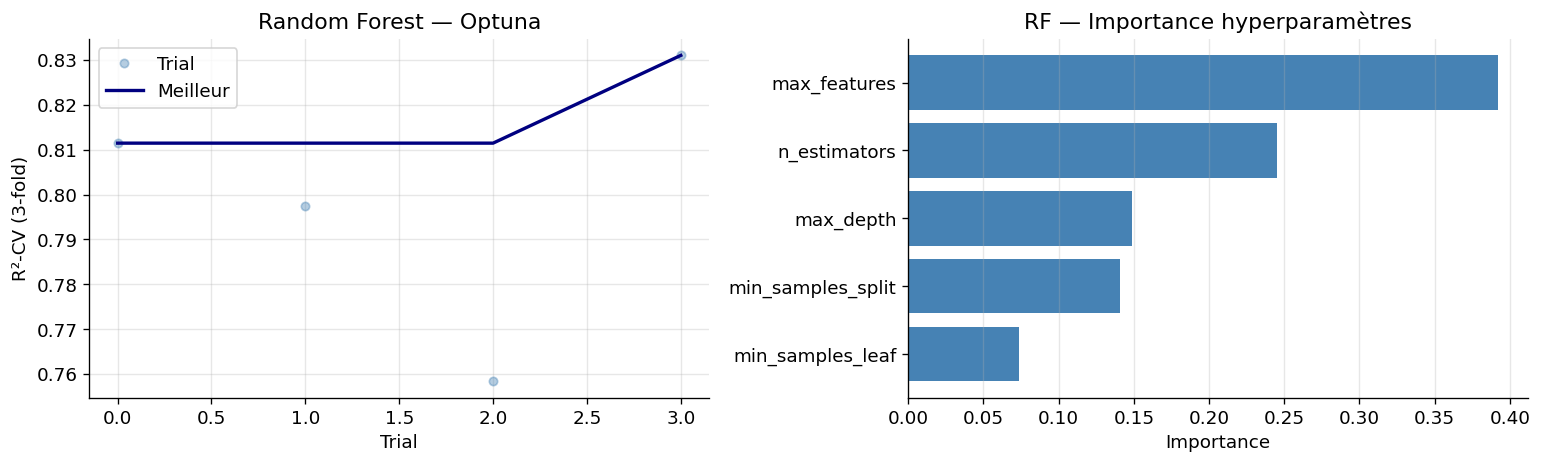

In [17]:
# ── Optuna RF ──────────────────────────────────────────────────────────────
if RUN_OPTUNA:
    from sklearn.model_selection import cross_val_score

    def objective_rf(trial):
        params = {
            "n_estimators":     trial.suggest_int("n_estimators", 200, 800, step=100),
            "max_depth":        trial.suggest_categorical("max_depth", [None, 15, 20, 30]),
            "max_features":     trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5]),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
            "min_samples_split":trial.suggest_int("min_samples_split", 2, 15),
            "oob_score":        False,
            "n_jobs":           -1,
            "random_state":     RANDOM_STATE,
        }
        scores = cross_val_score(
            RandomForestRegressor(**params), X_train_proc, y_train,
            cv=KFold(3, shuffle=True, random_state=RANDOM_STATE),
            scoring="r2", n_jobs=1,
        )
        return scores.mean()

    study_rf = optuna.create_study(direction="maximize",
                                   sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
                                   study_name="rf_reg")
    study_rf.enqueue_trial({"n_estimators": 500, "max_depth": None, "max_features": "sqrt",
                            "min_samples_leaf": 2, "min_samples_split": 2})
    study_rf.optimize(objective_rf, n_trials=N_TRIALS_RF, timeout=TIMEOUT_RF,
                      show_progress_bar=True)

    print(f"\n[RF] Meilleur R²-CV : {study_rf.best_value:.4f}")
    for k, v in study_rf.best_params.items():
        print(f"     {k:<22} = {v}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    vals = [t.value for t in study_rf.trials if t.value is not None]
    axes[0].plot(vals, "o", alpha=0.4, color="steelblue", ms=5, label="Trial")
    axes[0].plot([max(vals[:i+1]) for i in range(len(vals))], "-", color="navy", lw=2, label="Meilleur")
    axes[0].set(xlabel="Trial", ylabel="R²-CV (3-fold)", title="Random Forest — Optuna")
    axes[0].legend(); axes[0].grid(alpha=0.3)
    try:
        imp = optuna.importance.get_param_importances(study_rf)
        axes[1].barh(list(imp.keys())[::-1], list(imp.values())[::-1], color="steelblue")
        axes[1].set(xlabel="Importance", title="RF — Importance hyperparamètres")
        axes[1].grid(axis="x", alpha=0.3)
    except Exception:
        pass
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "reg_optuna_rf_history.png", dpi=130, bbox_inches="tight")
    plt.show()
else:
    print("Optuna RF ignoré.")
    study_rf = None

  0%|          | 0/60 [00:00<?, ?it/s]


[XGB] Meilleur R²-val : 0.8145
     n_estimators           = 1000
     learning_rate          = 0.05
     max_depth              = 6
     subsample              = 0.8
     colsample_bytree       = 0.8
     colsample_bylevel      = 1.0
     min_child_weight       = 3
     gamma                  = 0.1
     reg_alpha              = 0.1
     reg_lambda             = 1.0


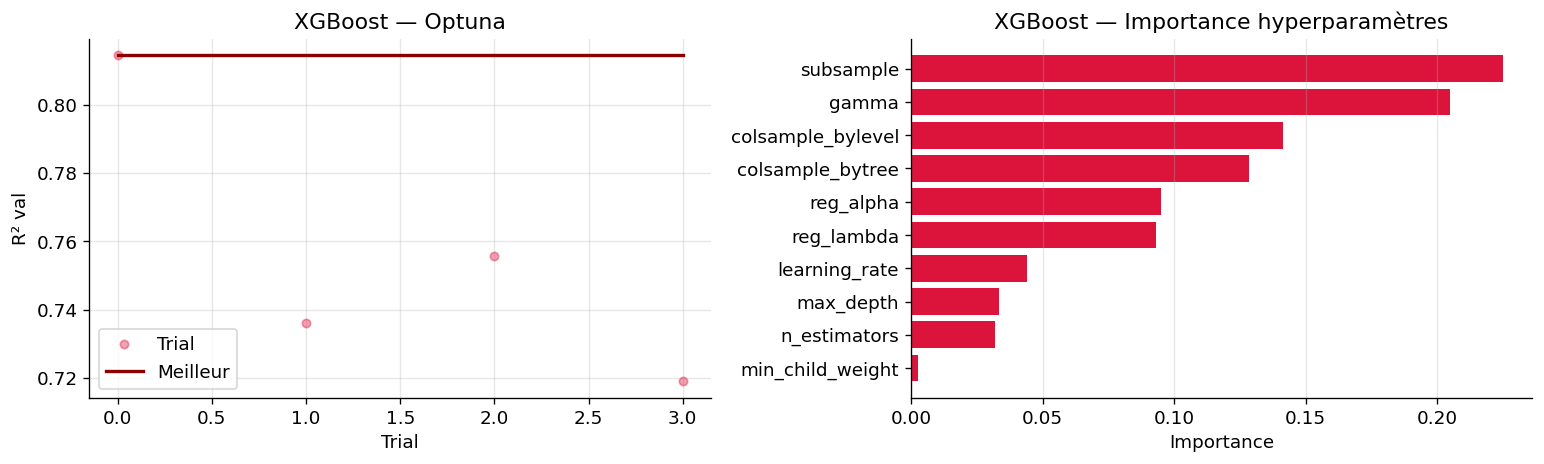

In [18]:
# ── Optuna XGBoost ───────────────────────────────────────────────────────────
if RUN_OPTUNA:
    X_opt_tr, X_opt_val, y_opt_tr, y_opt_val = train_test_split(
        X_train_proc, y_train, test_size=0.18, random_state=RANDOM_STATE)

    def objective_xgb(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 200, 2000, step=100),
            "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
            "max_depth":         trial.suggest_int("max_depth", 3, 12),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.4, 1.0),
            "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.4, 1.0),
            "min_child_weight":  trial.suggest_int("min_child_weight", 1, 15),
            "gamma":             trial.suggest_float("gamma", 0.0, 2.0),
            "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "tree_method":       "hist", "n_jobs": -1, "random_state": RANDOM_STATE,
            "eval_metric": "rmse", "objective": "reg:squarederror",
        }
        model = xgb.XGBRegressor(**params, early_stopping_rounds=40)
        model.fit(X_opt_tr, y_opt_tr, eval_set=[(X_opt_val, y_opt_val)], verbose=False)
        return r2_score(y_opt_val, model.predict(X_opt_val))

    study_xgb = optuna.create_study(direction="maximize",
                                    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
                                    pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
                                    study_name="xgb_reg")
    study_xgb.enqueue_trial({"n_estimators": 1000, "learning_rate": 0.05, "max_depth": 6,
                             "subsample": 0.8, "colsample_bytree": 0.8, "colsample_bylevel": 1.0,
                             "min_child_weight": 3, "gamma": 0.1, "reg_alpha": 0.1, "reg_lambda": 1.0})
    study_xgb.optimize(objective_xgb, n_trials=N_TRIALS_XGB, timeout=TIMEOUT_XGB,
                       show_progress_bar=True)

    print(f"\n[XGB] Meilleur R²-val : {study_xgb.best_value:.4f}")
    for k, v in study_xgb.best_params.items():
        print(f"     {k:<22} = {v}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    vals = [t.value for t in study_xgb.trials if t.value is not None]
    axes[0].plot(vals, "o", alpha=0.4, color="crimson", ms=5, label="Trial")
    axes[0].plot([max(vals[:i+1]) for i in range(len(vals))], "-", color="darkred", lw=2, label="Meilleur")
    axes[0].set(xlabel="Trial", ylabel="R² val", title="XGBoost — Optuna")
    axes[0].legend(); axes[0].grid(alpha=0.3)
    try:
        imp = optuna.importance.get_param_importances(study_xgb)
        axes[1].barh(list(imp.keys())[::-1], list(imp.values())[::-1], color="crimson")
        axes[1].set(xlabel="Importance", title="XGBoost — Importance hyperparamètres")
        axes[1].grid(axis="x", alpha=0.3)
    except Exception:
        pass
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "reg_optuna_xgb_history.png", dpi=130, bbox_inches="tight")
    plt.show()
else:
    print("Optuna XGBoost ignoré.")
    study_xgb = None

In [19]:
# ── Ré-entraînement avec les meilleurs hyperparamètres Optuna ────────────────
if RUN_OPTUNA and study_rf is not None and study_xgb is not None:
    # Random Forest
    best_rf_params = {**study_rf.best_params, "oob_score": True,
                      "n_jobs": -1, "random_state": RANDOM_STATE}
    print("Ré-entraînement RF (params Optuna)…")
    rf = RandomForestRegressor(**best_rf_params)
    rf.fit(X_train_proc, y_train)
    print(f"  OOB R² : {rf.oob_score_:.4f}")
    y_pred_rf  = rf.predict(X_test_proc)
    metrics_rf = evaluate_regression("RF (Optuna)", y_test, y_pred_rf)

    # XGBoost
    best_xgb_params = {**study_xgb.best_params, "tree_method": "hist", "n_jobs": -1,
                       "random_state": RANDOM_STATE, "eval_metric": "rmse",
                       "objective": "reg:squarederror"}
    print("\nRé-entraînement XGBoost (params Optuna)…")
    xgb_model = xgb.XGBRegressor(**best_xgb_params, early_stopping_rounds=50)
    xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    print(f"  Best iteration : {xgb_model.best_iteration}")
    y_pred_xgb  = xgb_model.predict(X_test_proc)
    metrics_xgb = evaluate_regression("XGB (Optuna)", y_test, y_pred_xgb)
else:
    print("Modèles non ré-entraînés — Optuna désactivé.")

Ré-entraînement RF (params Optuna)…
  OOB R² : 0.8584
══════════════════════════════════════════════════════════
  RF (Optuna)
──────────────────────────────────────────────────────────
  [échelle log10]
    R²                    : 0.8522
    RMSE                  : 0.1996
    MAE                   : 0.1005
    Median AE             : 0.0458
    Spearman ρ (rang)     : 0.9187
  [échelle ng/L]
    RMSE                  : 377.3 ng/L
    Median AE             : 3.9 ng/L
══════════════════════════════════════════════════════════

Ré-entraînement XGBoost (params Optuna)…
  Best iteration : 998
══════════════════════════════════════════════════════════
  XGB (Optuna)
──────────────────────────────────────────────────────────
  [échelle log10]
    R²                    : 0.8034
    RMSE                  : 0.2302
    MAE                   : 0.1348
    Median AE             : 0.0777
    Spearman ρ (rang)     : 0.8710
  [échelle ng/L]
    RMSE                  : 436.1 ng/L
    Median AE         

## 9. Comparaison des modèles

In [20]:
# ── Tableau comparatif ───────────────────────────────────────────────────────
comparison_df = pd.DataFrame([
    {
        "Modèle":        "Random Forest",
        "R² (test)":     metrics_rf["r2"],
        "RMSE log":      metrics_rf["rmse"],
        "MAE log":       metrics_rf["mae"],
        "Spearman ρ":    metrics_rf["spearman"],
        "RMSE ng/L":     metrics_rf["rmse_ngl"],
        "R² (CV)":   f"{cv_rf['test_r2'].mean():.4f}±{cv_rf['test_r2'].std():.4f}",
    },
    {
        "Modèle":        "XGBoost",
        "R² (test)":     metrics_xgb["r2"],
        "RMSE log":      metrics_xgb["rmse"],
        "MAE log":       metrics_xgb["mae"],
        "Spearman ρ":    metrics_xgb["spearman"],
        "RMSE ng/L":     metrics_xgb["rmse_ngl"],
        "R² (CV)":   f"{cv_xgb['test_r2'].mean():.4f}±{cv_xgb['test_r2'].std():.4f}",
    },
])
comparison_df.set_index("Modèle", inplace=True)
comparison_df.style.background_gradient(cmap="RdYlGn",
    subset=["R² (test)", "Spearman ρ"]).background_gradient(cmap="RdYlGn_r",
    subset=["RMSE log", "MAE log"])

,R² (test),RMSE log,MAE log,Spearman ρ,RMSE ng/L,R² (CV)
Modèle,,,,,,
Random Forest,0.852223,0.199611,0.100469,0.918726,377.293010,0.8247±0.0061
XGBoost,0.803404,0.230233,0.134832,0.871006,436.092515,0.8053±0.0079


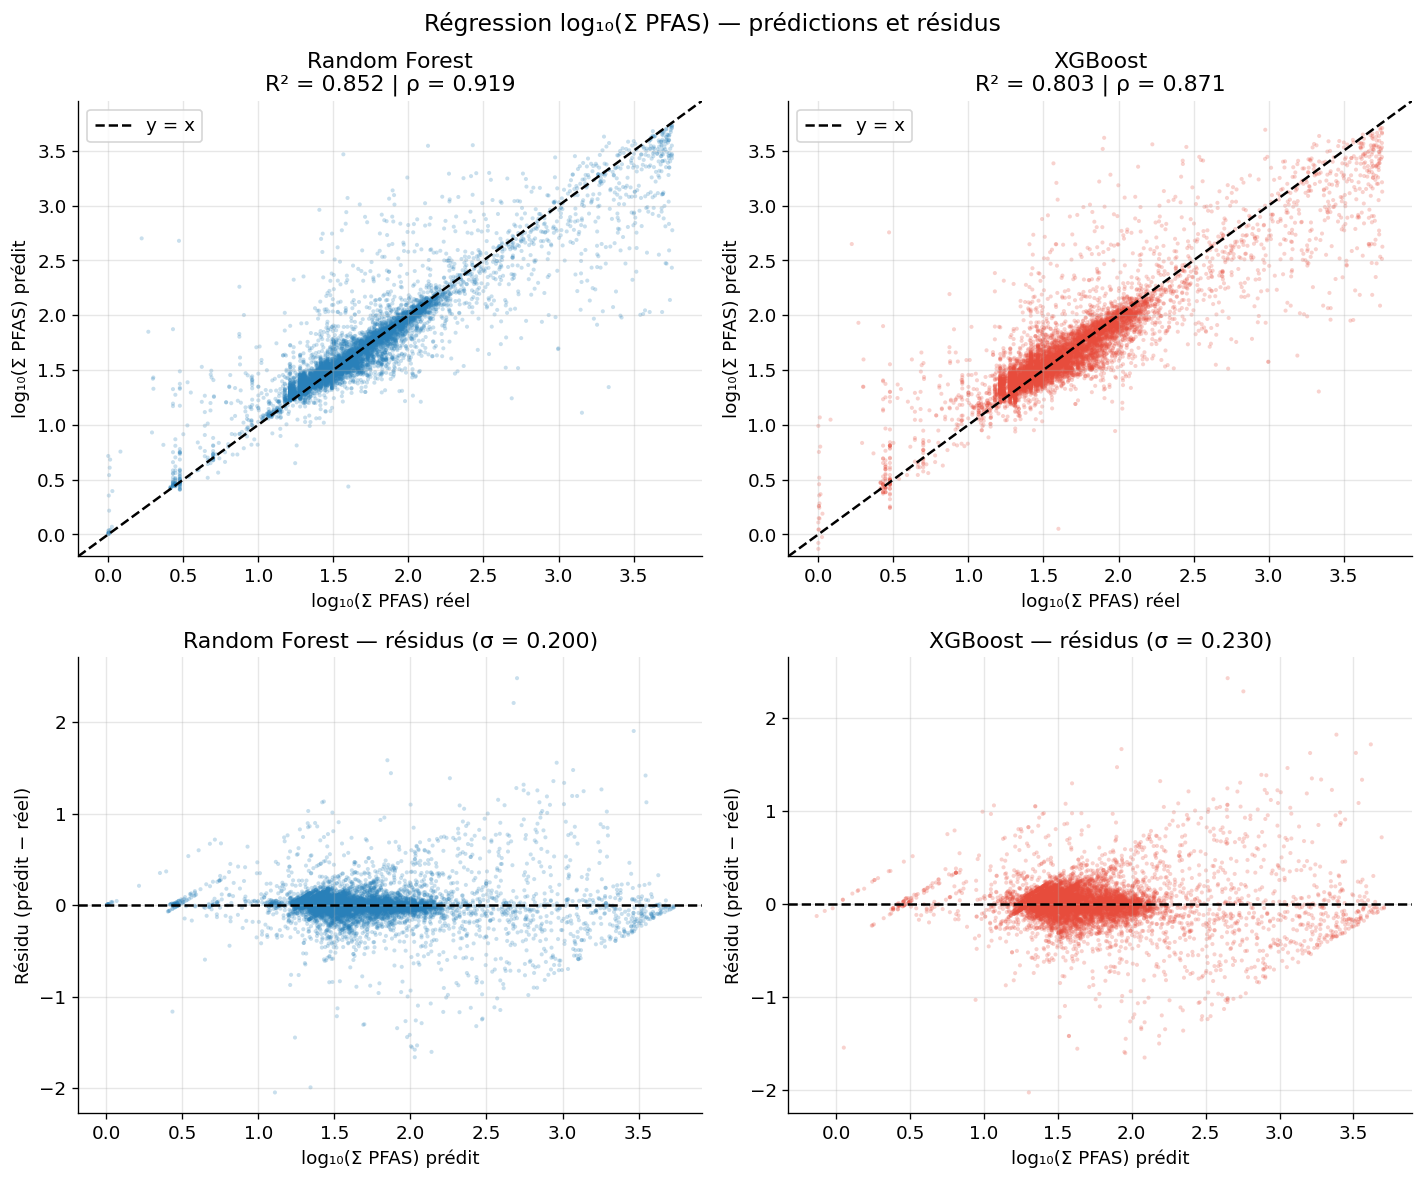

In [21]:
# ── Prédit vs réel + résidus ─────────────────────────────────────────────────
models_results = [
    ("Random Forest", y_pred_rf,  metrics_rf),
    ("XGBoost",       y_pred_xgb, metrics_xgb),
]
plot_pred_vs_actual(models_results, y_test,
                    title="Régression log₁₀(Σ PFAS) — prédictions et résidus")

## 10. Importance des features

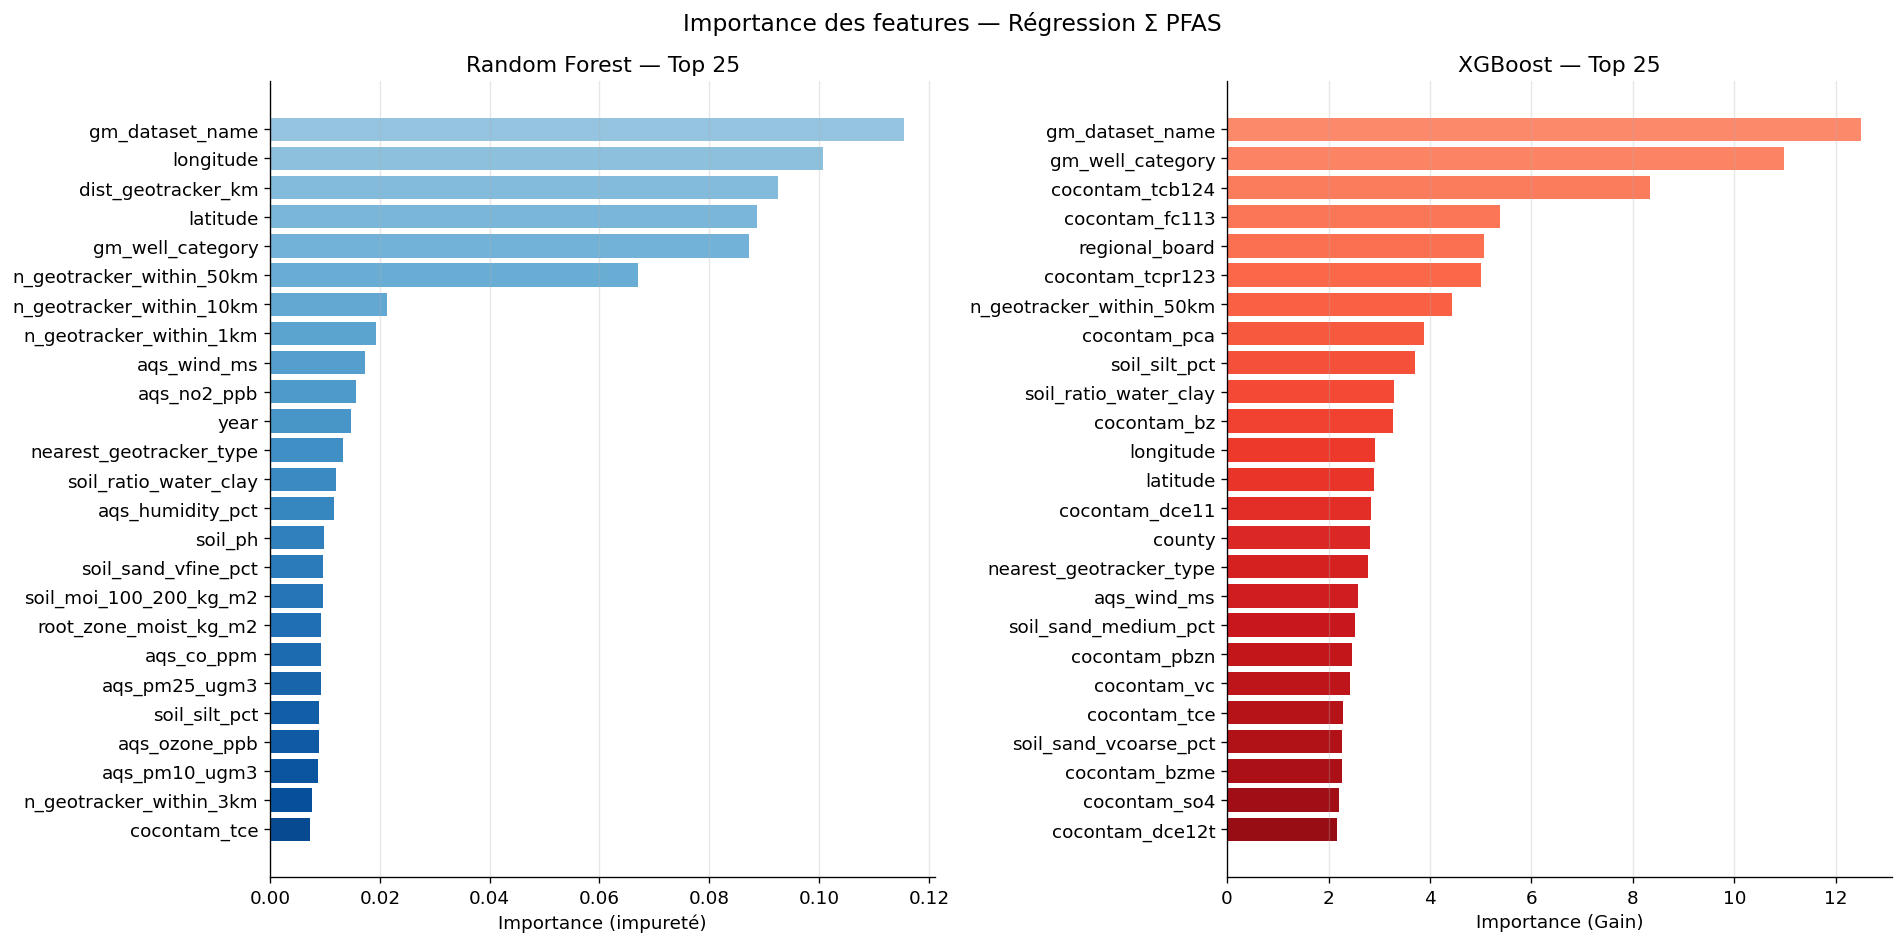

Top 15 features Random Forest :
 rank                  feature  importance
    1          gm_dataset_name    0.115415
    2                longitude    0.100724
    3       dist_geotracker_km    0.092509
    4                 latitude    0.088738
    5         gm_well_category    0.087329
    6 n_geotracker_within_50km    0.067060
    7 n_geotracker_within_10km    0.021247
    8  n_geotracker_within_1km    0.019328
    9              aqs_wind_ms    0.017383
   10              aqs_no2_ppb    0.015575
   11                     year    0.014837
   12  nearest_geotracker_type    0.013297
   13    soil_ratio_water_clay    0.012079
   14         aqs_humidity_pct    0.011671
   15                  soil_ph    0.009812


In [22]:
# ── Importance RF (impureté) + XGBoost (gain) ────────────────────────────────
fi_rf = pd.DataFrame({
    "feature":    feature_names,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)
fi_rf["rank"] = fi_rf.index + 1

xgb_gain = xgb_model.get_booster().get_score(importance_type="gain")
# mapping f0,f1,... → noms
fmap = {f"f{i}": name for i, name in enumerate(feature_names)}
fi_xgb = pd.DataFrame([
    {"feature": fmap.get(k, k), "xgb_gain": v} for k, v in xgb_gain.items()
]).sort_values("xgb_gain", ascending=False).reset_index(drop=True)
fi_xgb["rank_xgb"] = fi_xgb.index + 1

# ── Graphique côte à côte ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
top_n = 25

top_rf = fi_rf.head(top_n)
axes[0].barh(top_rf["feature"][::-1], top_rf["importance"][::-1],
             color=plt.cm.Blues(np.linspace(0.4, 0.9, top_n))[::-1])
axes[0].set(xlabel="Importance (impureté)", title=f"Random Forest — Top {top_n}")
axes[0].grid(axis="x", alpha=0.3)

top_xgb = fi_xgb.head(top_n)
axes[1].barh(top_xgb["feature"][::-1], top_xgb["xgb_gain"][::-1],
             color=plt.cm.Reds(np.linspace(0.4, 0.9, len(top_xgb)))[::-1])
axes[1].set(xlabel="Importance (Gain)", title=f"XGBoost — Top {top_n}")
axes[1].grid(axis="x", alpha=0.3)

fig.suptitle("Importance des features — Régression Σ PFAS", fontsize=14)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "reg_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 15 features Random Forest :")
print(fi_rf.head(15)[["rank", "feature", "importance"]].to_string(index=False))

## 11. Analyse SHAP (optionnel — lent ~2 min)

In [23]:
RUN_SHAP = False

if RUN_SHAP:
    import shap
    rng = np.random.RandomState(RANDOM_STATE)
    idx = rng.choice(len(X_test_proc), min(1500, len(X_test_proc)), replace=False)
    explainer = shap.TreeExplainer(xgb_model)
    shap_vals = explainer.shap_values(X_test_proc[idx])
    shap.summary_plot(shap_vals, X_test_proc[idx], feature_names=feature_names,
                      max_display=25, show=False)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "reg_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("SHAP désactivé (RUN_SHAP=False).")

SHAP désactivé (RUN_SHAP=False).


## 12. Sauvegarde des artefacts

In [24]:
# ── Modèles + préprocesseur ──────────────────────────────────────────────────
best_name = "XGBoost" if metrics_xgb["r2"] >= metrics_rf["r2"] else "Random Forest"
best_model = xgb_model if best_name == "XGBoost" else rf

artifact = {
    "preprocessor":  preprocessor,
    "model_rf":      rf,
    "model_xgb":     xgb_model,
    "best_model":    best_name,
    "feature_names": feature_names,
    "num_cols":      num_cols,
    "cat_cols":      cat_cols,
    "target":        "log10(sum_pfas_ngL + 1)",
}
with open(MODELS_DIR / "reg_sum_pfas.pkl", "wb") as f:
    pickle.dump(artifact, f)
print(f"Modèle sauvegardé → {MODELS_DIR / 'reg_sum_pfas.pkl'}  (meilleur : {best_name})")

# ── Importances ──────────────────────────────────────────────────────────────
fi_combined = fi_rf.rename(columns={"importance": "rf_importance", "rank": "rank_rf"}).merge(
    fi_xgb[["feature", "xgb_gain", "rank_xgb"]], on="feature", how="left")
fi_combined.to_csv(PROCESSED_DIR / "reg_feature_importance.csv", index=False)

# ── Résultats JSON ───────────────────────────────────────────────────────────
results = {
    "target":  "log10(sum_pfas_ngL + 1)",
    "n_train": int(len(y_train)),
    "n_test":  int(len(y_test)),
    "n_features": len(feature_names),
    "random_forest": {
        "test": {k: round(float(v), 4) for k, v in metrics_rf.items() if k != "name"},
        "cv_r2": f"{cv_rf['test_r2'].mean():.4f}±{cv_rf['test_r2'].std():.4f}",
    },
    "xgboost": {
        "test": {k: round(float(v), 4) for k, v in metrics_xgb.items() if k != "name"},
        "cv_r2": f"{cv_xgb['test_r2'].mean():.4f}±{cv_xgb['test_r2'].std():.4f}",
    },
    "top10_features_rf": fi_rf.head(10)[["rank", "feature", "importance"]].rename(
        columns={"importance": "rf_importance"}).to_dict("records"),
}
with open(PROCESSED_DIR / "reg_sum_pfas_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"Résultats → {PROCESSED_DIR / 'reg_sum_pfas_results.json'}")

Modèle sauvegardé → ../models/reg_sum_pfas.pkl  (meilleur : Random Forest)
Résultats → ../data/processed/reg_sum_pfas_results.json


## 13. Synthèse finale

In [25]:
print("╔══════════════════════════════════════════════════════════╗")
print("║      RÉSULTATS — Régression log₁₀(Σ PFAS)                 ║")
print("╚══════════════════════════════════════════════════════════╝")
print()
print(f"  Cible      : log₁₀(sum_pfas_ngL + 1)")
print(f"  Train/Test : {len(y_train):,} / {len(y_test):,}")
print(f"  Features   : {len(feature_names)}")
print()
print(f"  {'Modèle':<16}{'R²':>8}{'RMSE log':>11}{'Spearman':>11}{'RMSE ng/L':>12}")
print("  " + "─"*56)
for m in [metrics_rf, metrics_xgb]:
    print(f"  {m['name']:<16}{m['r2']:>8.4f}{m['rmse']:>11.4f}"
          f"{m['spearman']:>11.4f}{m['rmse_ngl']:>11.1f}")
print()
print(f"  Meilleur modèle : {best_name} (R² = {max(metrics_rf['r2'], metrics_xgb['r2']):.4f})")
print()
print("  Interprétation :")
print("    • R² mesure la variance expliquée sur l'échelle log")
print("    • Spearman ρ mesure la qualité du CLASSEMENT (rang de contamination)")
print("    • RMSE ng/L est sensible aux valeurs extrêmes (max 5723 ng/L)")
print()
print("  Top 5 features prédictives :")
for _, row in fi_rf.head(5).iterrows():
    print(f"    #{row['rank']:<3}{row['feature']:<32}{row['importance']:.4f}")

╔══════════════════════════════════════════════════════════╗
║      RÉSULTATS — Régression log₁₀(Σ PFAS)                 ║
╚══════════════════════════════════════════════════════════╝

  Cible      : log₁₀(sum_pfas_ngL + 1)
  Train/Test : 37,070 / 9,268
  Features   : 92

  Modèle                R²   RMSE log   Spearman   RMSE ng/L
  ────────────────────────────────────────────────────────
  RF (Optuna)       0.8522     0.1996     0.9187      377.3
  XGB (Optuna)      0.8034     0.2302     0.8710      436.1

  Meilleur modèle : Random Forest (R² = 0.8522)

  Interprétation :
    • R² mesure la variance expliquée sur l'échelle log
    • Spearman ρ mesure la qualité du CLASSEMENT (rang de contamination)
    • RMSE ng/L est sensible aux valeurs extrêmes (max 5723 ng/L)

  Top 5 features prédictives :
    #1  gm_dataset_name                 0.1154
    #2  longitude                       0.1007
    #3  dist_geotracker_km              0.0925
    #4  latitude                        0.0887
   